# Section 0. Setup

In [1]:
import os
import gc
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils import class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
import whisper
from transformers import pipeline
import torch
from collections import defaultdict
from datetime import datetime

# Reproducibility for Reviewer Validation
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

class Config:
    # Data Settings
    DATA_PATH = 'dataset_meld/'
    FILE_PREFIX = 'prepared_'
    SR = 16000
    MAX_DURATION = 3
    MAX_SAMPLES = SR * MAX_DURATION
    
    # Feature Settings
    N_MFCC = 40
    MAX_MFCC_LEN = 94  
    
    # Training Parameters 
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 30
    DROPOUT = 0.3
    
    DEFAULT_CLASSES = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']

print("=== Hyperparameters ===")
for k, v in vars(Config).items():
    if not k.startswith('__'): print(f"{k}: {v}")

c:\Users\User\Downloads\[YTS]Github\FYP\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Hyperparameters ===
DATA_PATH: dataset_meld/
FILE_PREFIX: prepared_
SR: 16000
MAX_DURATION: 3
MAX_SAMPLES: 48000
N_MFCC: 40
MAX_MFCC_LEN: 94
BATCH_SIZE: 32
LEARNING_RATE: 0.001
EPOCHS: 30
DROPOUT: 0.3
DEFAULT_CLASSES: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']


In [2]:
import shutil
import imageio_ffmpeg

# 1. Get the directory where imageio_ffmpeg stores its binary
ffmpeg_bin_dir = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())

# 2. Whisper looks specifically for "ffmpeg.exe". Let's make sure a copy exists with that exact name.
target_exe = os.path.join(ffmpeg_bin_dir, "ffmpeg.exe")
if not os.path.exists(target_exe):
    shutil.copy(imageio_ffmpeg.get_ffmpeg_exe(), target_exe)

# 3. Inject this directory into the system PATH for this session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_dir

# Section 1. Textual Sentiment (Feature Extraction)
- ASR & Sentiment Classifier

### test with GPU

In [3]:
import torch
print(torch.__version__)

2.11.0+cu128


In [4]:
# 1. Check GPU availability and set up device formatting
cuda_available = torch.cuda.is_available()
target_device = "cuda" if cuda_available else "cpu"
hf_device = 0 if cuda_available else -1

print(f"CUDA Available: {cuda_available}")
if cuda_available:
    print(f"Activating GPU: {torch.cuda.get_device_name(0)}\n")
else:
    print("GPU not detected. Running on CPU instead.\n")

CUDA Available: True
Activating GPU: NVIDIA GeForce RTX 5080 Laptop GPU



In [5]:
# 1. Load Whisper ASR
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

print("Loading Whisper ASR...")
asr_model_1 = whisper.load_model("base", device=target_device)

# 2. Load Wav2Vec 2.0 Processor and Model
print("Loading Wav2Vec 2.0 ASR...")
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
asr_model_2 = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h").to(target_device)

# 3. Load RoBERTa Sentiment Classifier on the target device
print("Loading RoBERTa Sentiment Classifier...")
sentiment_classifier = pipeline(
    "sentiment-analysis", 
    model="cardiffnlp/twitter-roberta-base-sentiment-latest", 
    device=hf_device
)

print("\n✅ Both models loaded and pinned to GPU successfully!")

Loading Whisper ASR...
Loading Wav2Vec 2.0 ASR...


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 11713.62it/s]
[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading RoBERTa Sentiment Classifier...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 50065.63it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Both models loaded and pinned to GPU successfully!



================ TRAIN SPLIT ================

Processing: dataset_meld\train_sent_emo.csv
⚠️ MOCK MODE ACTIVE: Processing only 10% of train (999 samples)


  0%|          | 0/999 [00:00<?, ?it/s]

100%|██████████| 999/999 [02:26<00:00,  6.82it/s]



✅ Finished train. Saved to dataset_meld\prepared_train_20260618_1659_sent_emo.csv

================ DEV SPLIT ================

Processing: dataset_meld\dev_sent_emo.csv
⚠️ MOCK MODE ACTIVE: Processing only 10% of dev (111 samples)


100%|██████████| 111/111 [00:18<00:00,  6.12it/s]



✅ Finished dev. Saved to dataset_meld\prepared_dev_20260618_1659_sent_emo.csv

================ TEST SPLIT ================

Processing: dataset_meld\test_sent_emo.csv
⚠️ MOCK MODE ACTIVE: Processing only 10% of test (261 samples)


100%|██████████| 261/261 [00:36<00:00,  7.16it/s]



✅ Finished test. Saved to dataset_meld\prepared_test_20260618_1659_sent_emo.csv

================ FINAL DATASET REPORT ================

Success samples           : 1321
Missing audio             : 0
Invalid CSV data          : 0
ASR failed                : 0
Empty transcription       : 50
Sentiment prediction fail : 0
TOTAL FAILURES            : 50
------------------------------------------------------
Average WER               : 0.6002
Average Sentiment Score   : 0.7168

Failure log saved: dataset_meld/failed_samples_log_20260618_1659.csv


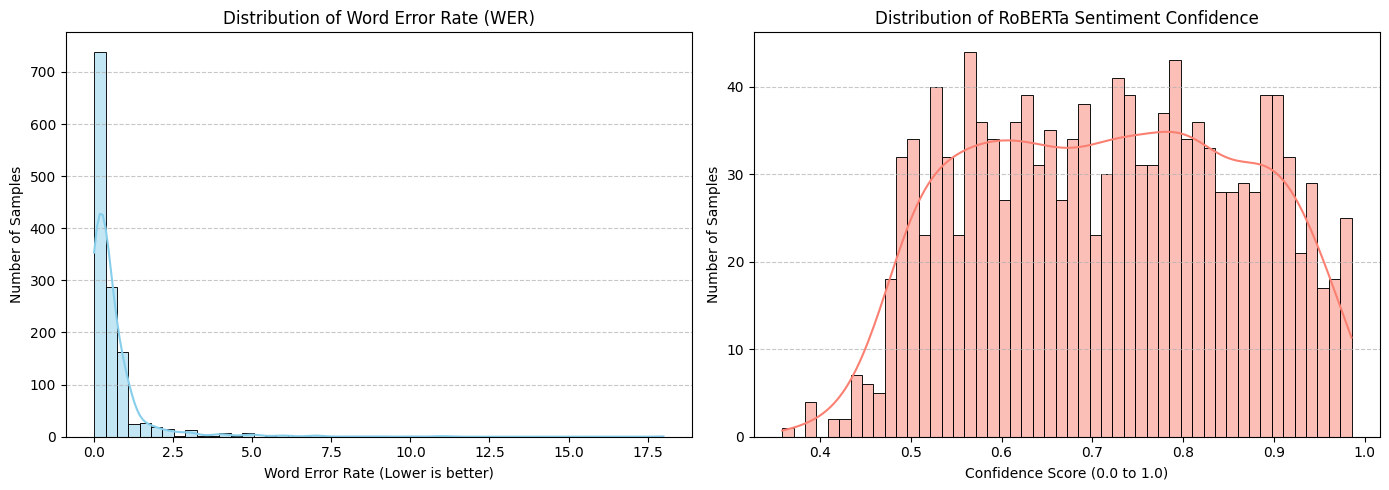

In [8]:
# asr 1
import jiwer

AUDIO_DIRECTORY = "dataset_meld/audio/"
AUDIO_EXT = ".wav"
splits = ['train', 'dev', 'test']

os.makedirs("dataset_meld", exist_ok=True)

# Create a timestamp string for the filenames (e.g., "20260617_2030")
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# --- GLOBAL STATS (per split) ---
stats = defaultdict(int)
failed_samples = []

# Lists to collect data for final graphs
global_wers = []
global_sentiment_scores = []

# Define the text transformation pipeline for accurate WER comparison (Text Normalisation)
transformation = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip()
])

# --- PROCESSING LOOP ---
for split in splits:
    print(f"\n================ {split.upper()} SPLIT ================\n")

    orig_csv = os.path.join("dataset_meld", f"{split}_sent_emo.csv")
    out_csv = os.path.join("dataset_meld", f"prepared_{split}_{timestamp}_sent_emo.csv")

    print(f"Processing: {orig_csv}")
    df = pd.read_csv(orig_csv)

    # --- MOCK RUN MECHANISM ---
    MOCK_MODE = True  # Toggle this to False to run the full dataset
    if MOCK_MODE:
        # Take 10% of the data, sampled randomly
        df = df.sample(frac=0.10, random_state=SEED) 
        print(f"⚠️ MOCK MODE ACTIVE: Processing only 10% of {split} ({len(df)} samples)")
    # --------------------------

    prepared_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        dia_id = row['Dialogue_ID']
        utt_id = row['Utterance_ID']

        raw_path = os.path.join(
            AUDIO_DIRECTORY,
            f"wav_{split}",
            f"dia{dia_id}_utt{utt_id}{AUDIO_EXT}"
        )
        file_path = os.path.abspath(raw_path)

        # ---------------------------
        # Missing audio
        # ---------------------------
        if not os.path.exists(file_path):
            stats["missing_audio"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "missing_audio"
            })
            continue

        # ---------------------------
        # Validate CSV fields
        # ---------------------------
        if pd.isna(row['Emotion']) or pd.isna(row['Sentiment']) or pd.isna(row['Utterance']):
            stats["invalid_csv_data"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "invalid_csv_data"
            })
            continue

        emo_gt = str(row['Emotion']).lower()
        sent_gt = str(row['Sentiment']).lower()
        trans_gt = str(row['Utterance']).strip()

        # ---------------------------
        # ASR transcription (Whisper)
        # ---------------------------
        try:
            with torch.no_grad():
                trans_asr = asr_model_1.transcribe(
                    file_path,
                    fp16=True,
                    language="en",
                    task="transcribe"
                )['text'].strip()

        except Exception as e:
            stats["asr_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "asr_failed", "error": str(e)
            })
            continue

        if not trans_asr:
            stats["empty_transcription"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "empty_transcription"
            })
            continue

        # ---------------------------
        # WER Calculation (Text Normalisation applied)
        # ---------------------------
        wer_score = jiwer.wer(transformation(trans_gt), transformation(trans_asr))

        # ---------------------------
        # Sentiment prediction
        # ---------------------------
        try:
            bert_out = sentiment_classifier(trans_asr)[0]
            sent_pred = bert_out['label'].lower()
            sent_score = bert_out['score']

        except Exception as e:
            stats["sentiment_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "sentiment_failed", "error": str(e)
            })
            continue

        # ---------------------------
        # SUCCESS CASE
        # ---------------------------
        prepared_data.append({
            'emotion': emo_gt,
            'sentiment': sent_gt,  
            'textual_sentiment_predicted': sent_pred,
            'textual_sentiment_score': sent_score,
            'transcription_ground_truth': trans_gt,
            'transcription_ASR': trans_asr,
            'WER': wer_score,
            'file_path': file_path
        })

        stats["success"] += 1
        global_wers.append(wer_score)
        global_sentiment_scores.append(sent_score)

    # ---------------------------
    # Save entire batch at once (Optimised for GPU speed)
    # ---------------------------
    if prepared_data:
        chunk_df = pd.DataFrame(prepared_data)
        chunk_df.to_csv(out_csv, index=False)

    print(f"\n✅ Finished {split}. Saved to {out_csv}")
# ---------------------------
# FINAL REPORT
# ---------------------------
print("\n================ FINAL DATASET REPORT ================\n")

total_failures = (
    stats["missing_audio"] + stats["invalid_csv_data"] +
    stats["asr_failed"] + stats["empty_transcription"] +
    stats["sentiment_failed"]
)

# Calculate Averages
avg_wer = sum(global_wers) / len(global_wers) if global_wers else 0
avg_sent = sum(global_sentiment_scores) / len(global_sentiment_scores) if global_sentiment_scores else 0

print(f"Success samples           : {stats['success']}")
print(f"Missing audio             : {stats['missing_audio']}")
print(f"Invalid CSV data          : {stats['invalid_csv_data']}")
print(f"ASR failed                : {stats['asr_failed']}")
print(f"Empty transcription       : {stats['empty_transcription']}")
print(f"Sentiment prediction fail : {stats['sentiment_failed']}")
print(f"TOTAL FAILURES            : {total_failures}")
print("-" * 54)
print(f"Average WER               : {avg_wer:.4f}")
print(f"Average Sentiment Score   : {avg_sent:.4f}")

# ---------------------------
# SAVE FAILURE LOG
# ---------------------------
failed_df = pd.DataFrame(failed_samples)
log_filename = f"dataset_meld/failed_samples_log_{timestamp}.csv"
failed_df.to_csv(log_filename, index=False)

print(f"\nFailure log saved: {log_filename}")

# ---------------------------
# GENERATE DISTRIBUTION GRAPHS
# ---------------------------
if global_wers and global_sentiment_scores:
    plt.figure(figsize=(14, 5))

    # Graph 1: WER Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(global_wers, bins=50, kde=True, color='skyblue')
    plt.title("Distribution of Word Error Rate (WER)")
    plt.xlabel("Word Error Rate (Lower is better)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Graph 2: Sentiment Score Distribution
    plt.subplot(1, 2, 2)
    sns.histplot(global_sentiment_scores, bins=50, kde=True, color='salmon')
    plt.title("Distribution of RoBERTa Sentiment Confidence")
    plt.xlabel("Confidence Score (0.0 to 1.0)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


================ TRAIN SPLIT ================

Processing: dataset_meld\train_sent_emo.csv
⚠️ MOCK MODE ACTIVE: Processing only 10% of train (999 samples)


100%|██████████| 999/999 [00:16<00:00, 62.05it/s]



✅ Finished train. Saved to dataset_meld\prepared_train_20260618_1710_sent_emo.csv

================ DEV SPLIT ================

Processing: dataset_meld\dev_sent_emo.csv
⚠️ MOCK MODE ACTIVE: Processing only 10% of dev (111 samples)


100%|██████████| 111/111 [00:01<00:00, 59.84it/s]



✅ Finished dev. Saved to dataset_meld\prepared_dev_20260618_1710_sent_emo.csv

================ TEST SPLIT ================

Processing: dataset_meld\test_sent_emo.csv
⚠️ MOCK MODE ACTIVE: Processing only 10% of test (261 samples)


100%|██████████| 261/261 [00:03<00:00, 65.43it/s]



✅ Finished test. Saved to dataset_meld\prepared_test_20260618_1710_sent_emo.csv

================ FINAL DATASET REPORT ================

Success samples           : 1371
Missing audio             : 0
Invalid CSV data          : 0
ASR failed                : 0
Empty transcription       : 0
Sentiment prediction fail : 0
TOTAL FAILURES            : 0
------------------------------------------------------
Average WER               : 0.8077
Average Sentiment Score   : 0.6960

Failure log saved: dataset_meld/failed_samples_log_20260618_1710.csv


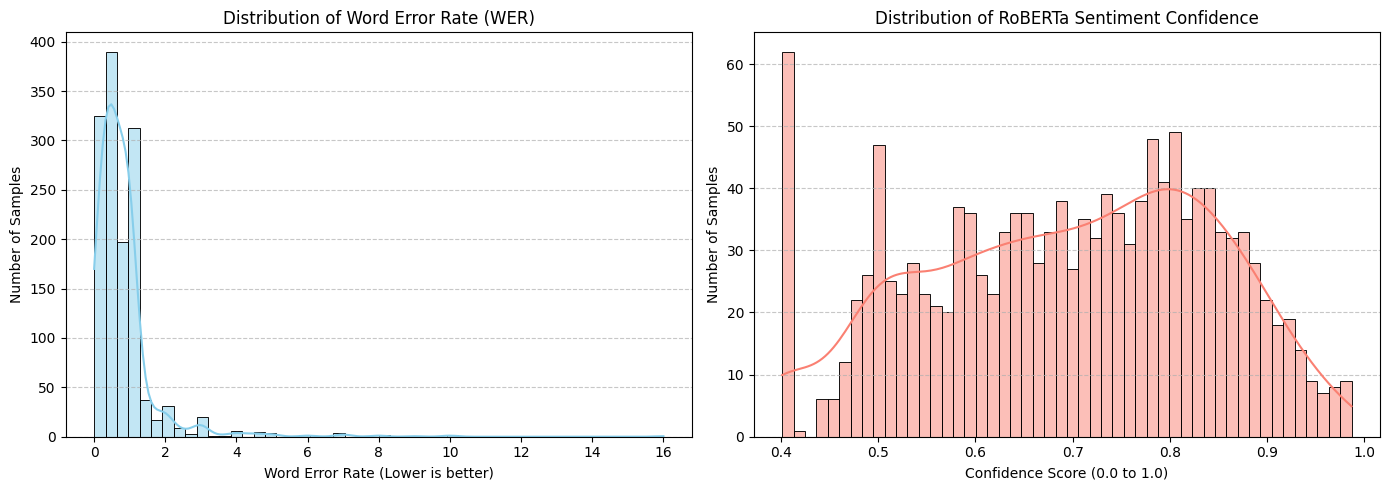

In [10]:
# asr 2
import jiwer

AUDIO_DIRECTORY = "dataset_meld/audio/"
AUDIO_EXT = ".wav"
splits = ['train', 'dev', 'test']

os.makedirs("dataset_meld", exist_ok=True)

# Create a timestamp string for the filenames (e.g., "20260617_2030")
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# --- GLOBAL STATS (per split) ---
stats = defaultdict(int)
failed_samples = []

# Lists to collect data for final graphs
global_wers = []
global_sentiment_scores = []

# Define the text transformation pipeline for accurate WER comparison (Text Normalisation)
transformation = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip()
])

# --- PROCESSING LOOP ---
for split in splits:
    print(f"\n================ {split.upper()} SPLIT ================\n")

    orig_csv = os.path.join("dataset_meld", f"{split}_sent_emo.csv")
    out_csv = os.path.join("dataset_meld", f"prepared_{split}_{timestamp}_sent_emo.csv")

    print(f"Processing: {orig_csv}")
    df = pd.read_csv(orig_csv)

    # --- MOCK RUN MECHANISM ---
    MOCK_MODE = True  # Toggle this to False to run the full dataset
    if MOCK_MODE:
        # Take 10% of the data, sampled randomly
        df = df.sample(frac=0.10, random_state=SEED) 
        print(f"⚠️ MOCK MODE ACTIVE: Processing only 10% of {split} ({len(df)} samples)")
    # --------------------------

    prepared_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        dia_id = row['Dialogue_ID']
        utt_id = row['Utterance_ID']

        raw_path = os.path.join(
            AUDIO_DIRECTORY,
            f"wav_{split}",
            f"dia{dia_id}_utt{utt_id}{AUDIO_EXT}"
        )
        file_path = os.path.abspath(raw_path)

        # ---------------------------
        # Missing audio
        # ---------------------------
        if not os.path.exists(file_path):
            stats["missing_audio"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "missing_audio"
            })
            continue

        # ---------------------------
        # Validate CSV fields
        # ---------------------------
        if pd.isna(row['Emotion']) or pd.isna(row['Sentiment']) or pd.isna(row['Utterance']):
            stats["invalid_csv_data"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "invalid_csv_data"
            })
            continue

        emo_gt = str(row['Emotion']).lower()
        sent_gt = str(row['Sentiment']).lower()
        trans_gt = str(row['Utterance']).strip()

        # ---------------------------
        # ASR transcription (Wav2Vec 2.0)
        # ---------------------------
        try:
            # Wav2Vec 2.0 REQUIRES 16kHz audio. Librosa handles this automatically.
            speech_array, sampling_rate = librosa.load(file_path, sr=16000)
            
            # Process the audio array into the tensor format the model expects
            input_values = processor(
                speech_array, 
                return_tensors="pt", 
                sampling_rate=16000
            ).input_values.to("cuda")

            # Perform transcription while bypassing the cuDNN 1D Conv bug
            with torch.no_grad():
                with torch.backends.cudnn.flags(enabled=False): # <--- THE MAGIC FIX
                    logits = asr_model_2(input_values).logits
            
            # Decode the predicted IDs back into text
            predicted_ids = torch.argmax(logits, dim=-1)
            trans_asr = processor.batch_decode(predicted_ids)[0]
            
            # Wav2Vec outputs all UPPERCASE without punctuation. 
            # Lowercase it here to keep it consistent with your pipeline.
            trans_asr = trans_asr.lower().strip()

        except Exception as e:
            stats["asr_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "asr_failed", "error": str(e)
            })
            continue
        
        # ---------------------------
        # WER Calculation (Text Normalisation applied)
        # ---------------------------
        wer_score = jiwer.wer(transformation(trans_gt), transformation(trans_asr))

        # ---------------------------
        # Sentiment prediction
        # ---------------------------
        try:
            bert_out = sentiment_classifier(trans_asr)[0]
            sent_pred = bert_out['label'].lower()
            sent_score = bert_out['score']

        except Exception as e:
            stats["sentiment_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "sentiment_failed", "error": str(e)
            })
            continue

        # ---------------------------
        # SUCCESS CASE
        # ---------------------------
        prepared_data.append({
            'emotion': emo_gt,
            'sentiment': sent_gt,  
            'textual_sentiment_predicted': sent_pred,
            'textual_sentiment_score': sent_score,
            'transcription_ground_truth': trans_gt,
            'transcription_ASR': trans_asr,
            'WER': wer_score,
            'file_path': file_path
        })

        stats["success"] += 1
        global_wers.append(wer_score)
        global_sentiment_scores.append(sent_score)

    # ---------------------------
    # Save entire batch at once (Optimised for GPU speed)
    # ---------------------------
    if prepared_data:
        chunk_df = pd.DataFrame(prepared_data)
        chunk_df.to_csv(out_csv, index=False)

    print(f"\n✅ Finished {split}. Saved to {out_csv}")

# ---------------------------
# FINAL REPORT
# ---------------------------
print("\n================ FINAL DATASET REPORT ================\n")

total_failures = (
    stats["missing_audio"] + stats["invalid_csv_data"] +
    stats["asr_failed"] + stats["empty_transcription"] +
    stats["sentiment_failed"]
)

# Calculate Averages
avg_wer = sum(global_wers) / len(global_wers) if global_wers else 0
avg_sent = sum(global_sentiment_scores) / len(global_sentiment_scores) if global_sentiment_scores else 0

print(f"Success samples           : {stats['success']}")
print(f"Missing audio             : {stats['missing_audio']}")
print(f"Invalid CSV data          : {stats['invalid_csv_data']}")
print(f"ASR failed                : {stats['asr_failed']}")
print(f"Empty transcription       : {stats['empty_transcription']}")
print(f"Sentiment prediction fail : {stats['sentiment_failed']}")
print(f"TOTAL FAILURES            : {total_failures}")
print("-" * 54)
print(f"Average WER               : {avg_wer:.4f}")
print(f"Average Sentiment Score   : {avg_sent:.4f}")

# ---------------------------
# SAVE FAILURE LOG
# ---------------------------
failed_df = pd.DataFrame(failed_samples)
log_filename = f"dataset_meld/failed_samples_log_{timestamp}.csv"
failed_df.to_csv(log_filename, index=False)

print(f"\nFailure log saved: {log_filename}")

# ---------------------------
# GENERATE DISTRIBUTION GRAPHS
# ---------------------------
if global_wers and global_sentiment_scores:
    plt.figure(figsize=(14, 5))

    # Graph 1: WER Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(global_wers, bins=50, kde=True, color='skyblue')
    plt.title("Distribution of Word Error Rate (WER)")
    plt.xlabel("Word Error Rate (Lower is better)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Graph 2: Sentiment Score Distribution
    plt.subplot(1, 2, 2)
    sns.histplot(global_sentiment_scores, bins=50, kde=True, color='salmon')
    plt.title("Distribution of RoBERTa Sentiment Confidence")
    plt.xlabel("Confidence Score (0.0 to 1.0)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

## Whole Dataset


================ TRAIN SPLIT ================

Processing: dataset_meld\train_sent_emo.csv


100%|██████████| 9989/9989 [25:45<00:00,  6.47it/s]  



✅ Finished train. Saved to dataset_meld\prepared_train_20260618_1713_sent_emo.csv

================ DEV SPLIT ================

Processing: dataset_meld\dev_sent_emo.csv


100%|██████████| 1109/1109 [02:49<00:00,  6.55it/s]



✅ Finished dev. Saved to dataset_meld\prepared_dev_20260618_1713_sent_emo.csv

================ TEST SPLIT ================

Processing: dataset_meld\test_sent_emo.csv


100%|██████████| 2610/2610 [02:19<00:00, 18.66it/s] 



✅ Finished test. Saved to dataset_meld\prepared_test_20260618_1713_sent_emo.csv

================ FINAL DATASET REPORT ================

Success samples           : 11054
Missing audio             : 2
Invalid CSV data          : 0
ASR failed                : 2261
Empty transcription       : 390
Sentiment prediction fail : 1
TOTAL FAILURES            : 2654
------------------------------------------------------
Average WER               : 0.6197
Average Sentiment Score   : 0.7158

Failure log saved: dataset_meld/failed_samples_log_20260618_1713.csv


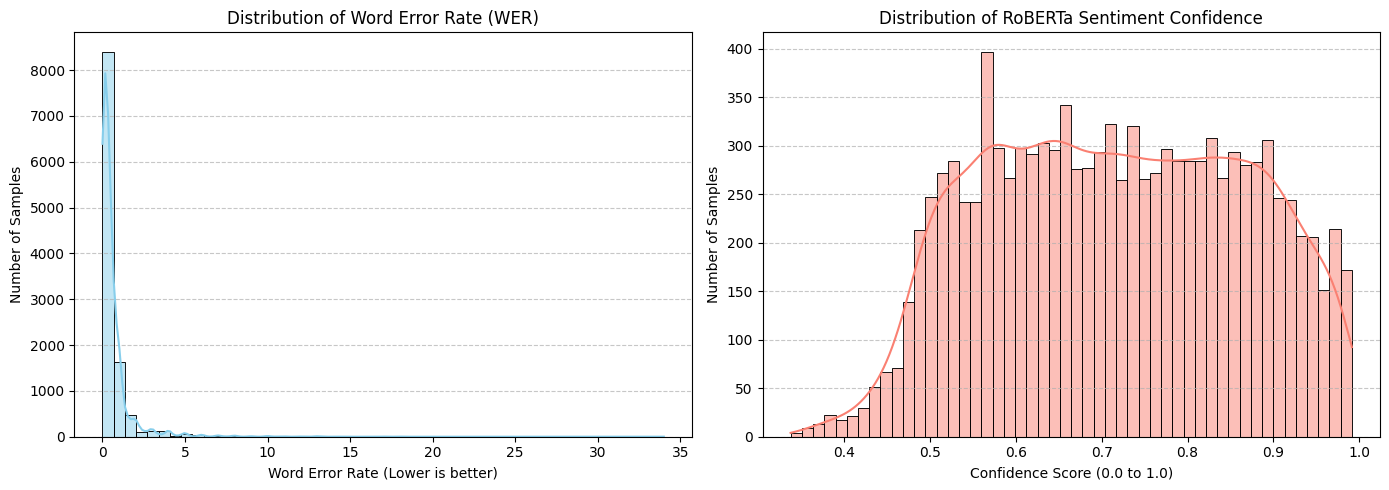

In [11]:
# asr 1
import jiwer

AUDIO_DIRECTORY = "dataset_meld/audio/"
AUDIO_EXT = ".wav"
splits = ['train', 'dev', 'test']

os.makedirs("dataset_meld", exist_ok=True)

# Create a timestamp string for the filenames (e.g., "20260617_2030")
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# --- GLOBAL STATS (per split) ---
stats = defaultdict(int)
failed_samples = []

# Lists to collect data for final graphs
global_wers = []
global_sentiment_scores = []

# Define the text transformation pipeline for accurate WER comparison (Text Normalisation)
transformation = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip()
])

# --- PROCESSING LOOP ---
for split in splits:
    print(f"\n================ {split.upper()} SPLIT ================\n")

    orig_csv = os.path.join("dataset_meld", f"{split}_sent_emo.csv")
    out_csv = os.path.join("dataset_meld", f"prepared_{split}_{timestamp}_sent_emo.csv")

    print(f"Processing: {orig_csv}")
    df = pd.read_csv(orig_csv)

    # --- MOCK RUN MECHANISM ---
    MOCK_MODE = False  # Toggle this to False to run the full dataset
    if MOCK_MODE:
        # Take 10% of the data, sampled randomly
        df = df.sample(frac=0.10, random_state=SEED) 
        print(f"⚠️ MOCK MODE ACTIVE: Processing only 10% of {split} ({len(df)} samples)")
    # --------------------------

    prepared_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        dia_id = row['Dialogue_ID']
        utt_id = row['Utterance_ID']

        raw_path = os.path.join(
            AUDIO_DIRECTORY,
            f"wav_{split}",
            f"dia{dia_id}_utt{utt_id}{AUDIO_EXT}"
        )
        file_path = os.path.abspath(raw_path)

        # ---------------------------
        # Missing audio
        # ---------------------------
        if not os.path.exists(file_path):
            stats["missing_audio"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "missing_audio"
            })
            continue

        # ---------------------------
        # Validate CSV fields
        # ---------------------------
        if pd.isna(row['Emotion']) or pd.isna(row['Sentiment']) or pd.isna(row['Utterance']):
            stats["invalid_csv_data"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "invalid_csv_data"
            })
            continue

        emo_gt = str(row['Emotion']).lower()
        sent_gt = str(row['Sentiment']).lower()
        trans_gt = str(row['Utterance']).strip()

        # ---------------------------
        # ASR transcription (Whisper)
        # ---------------------------
        try:
            with torch.no_grad():
                trans_asr = asr_model_1.transcribe(
                    file_path,
                    fp16=True,
                    language="en",
                    task="transcribe"
                )['text'].strip()

        except Exception as e:
            stats["asr_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "asr_failed", "error": str(e)
            })
            continue

        if not trans_asr:
            stats["empty_transcription"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "empty_transcription"
            })
            continue

        # ---------------------------
        # WER Calculation (Text Normalisation applied)
        # ---------------------------
        wer_score = jiwer.wer(transformation(trans_gt), transformation(trans_asr))

        # ---------------------------
        # Sentiment prediction
        # ---------------------------
        try:
            bert_out = sentiment_classifier(trans_asr)[0]
            sent_pred = bert_out['label'].lower()
            sent_score = bert_out['score']

        except Exception as e:
            stats["sentiment_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "sentiment_failed", "error": str(e)
            })
            continue

        # ---------------------------
        # SUCCESS CASE
        # ---------------------------
        prepared_data.append({
            'emotion': emo_gt,
            'sentiment': sent_gt,  
            'textual_sentiment_predicted': sent_pred,
            'textual_sentiment_score': sent_score,
            'transcription_ground_truth': trans_gt,
            'transcription_ASR': trans_asr,
            'WER': wer_score,
            'file_path': file_path
        })

        stats["success"] += 1
        global_wers.append(wer_score)
        global_sentiment_scores.append(sent_score)

    # ---------------------------
    # Save entire batch at once (Optimised for GPU speed)
    # ---------------------------
    if prepared_data:
        chunk_df = pd.DataFrame(prepared_data)
        chunk_df.to_csv(out_csv, index=False)

    print(f"\n✅ Finished {split}. Saved to {out_csv}")
# ---------------------------
# FINAL REPORT
# ---------------------------
print("\n================ FINAL DATASET REPORT ================\n")

total_failures = (
    stats["missing_audio"] + stats["invalid_csv_data"] +
    stats["asr_failed"] + stats["empty_transcription"] +
    stats["sentiment_failed"]
)

# Calculate Averages
avg_wer = sum(global_wers) / len(global_wers) if global_wers else 0
avg_sent = sum(global_sentiment_scores) / len(global_sentiment_scores) if global_sentiment_scores else 0

print(f"Success samples           : {stats['success']}")
print(f"Missing audio             : {stats['missing_audio']}")
print(f"Invalid CSV data          : {stats['invalid_csv_data']}")
print(f"ASR failed                : {stats['asr_failed']}")
print(f"Empty transcription       : {stats['empty_transcription']}")
print(f"Sentiment prediction fail : {stats['sentiment_failed']}")
print(f"TOTAL FAILURES            : {total_failures}")
print("-" * 54)
print(f"Average WER               : {avg_wer:.4f}")
print(f"Average Sentiment Score   : {avg_sent:.4f}")

# ---------------------------
# SAVE FAILURE LOG
# ---------------------------
failed_df = pd.DataFrame(failed_samples)
log_filename = f"dataset_meld/failed_samples_log_{timestamp}.csv"
failed_df.to_csv(log_filename, index=False)

print(f"\nFailure log saved: {log_filename}")

# ---------------------------
# GENERATE DISTRIBUTION GRAPHS
# ---------------------------
if global_wers and global_sentiment_scores:
    plt.figure(figsize=(14, 5))

    # Graph 1: WER Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(global_wers, bins=50, kde=True, color='skyblue')
    plt.title("Distribution of Word Error Rate (WER)")
    plt.xlabel("Word Error Rate (Lower is better)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Graph 2: Sentiment Score Distribution
    plt.subplot(1, 2, 2)
    sns.histplot(global_sentiment_scores, bins=50, kde=True, color='salmon')
    plt.title("Distribution of RoBERTa Sentiment Confidence")
    plt.xlabel("Confidence Score (0.0 to 1.0)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


================ TRAIN SPLIT ================

Processing: dataset_meld\train_sent_emo.csv


100%|██████████| 9989/9989 [02:30<00:00, 66.22it/s]



✅ Finished train. Saved to dataset_meld\prepared_train_20260618_1748_sent_emo.csv

================ DEV SPLIT ================

Processing: dataset_meld\dev_sent_emo.csv


100%|██████████| 1109/1109 [00:16<00:00, 67.98it/s]



✅ Finished dev. Saved to dataset_meld\prepared_dev_20260618_1748_sent_emo.csv

================ TEST SPLIT ================

Processing: dataset_meld\test_sent_emo.csv


100%|██████████| 2610/2610 [00:08<00:00, 309.02it/s] 



✅ Finished test. Saved to dataset_meld\prepared_test_20260618_1748_sent_emo.csv

================ FINAL DATASET REPORT ================

Success samples           : 11444
Missing audio             : 2
Invalid CSV data          : 0
ASR failed                : 2261
Empty transcription       : 0
Sentiment prediction fail : 1
TOTAL FAILURES            : 2264
------------------------------------------------------
Average WER               : 0.8296
Average Sentiment Score   : 0.6993

Failure log saved: dataset_meld/failed_samples_log_20260618_1748.csv


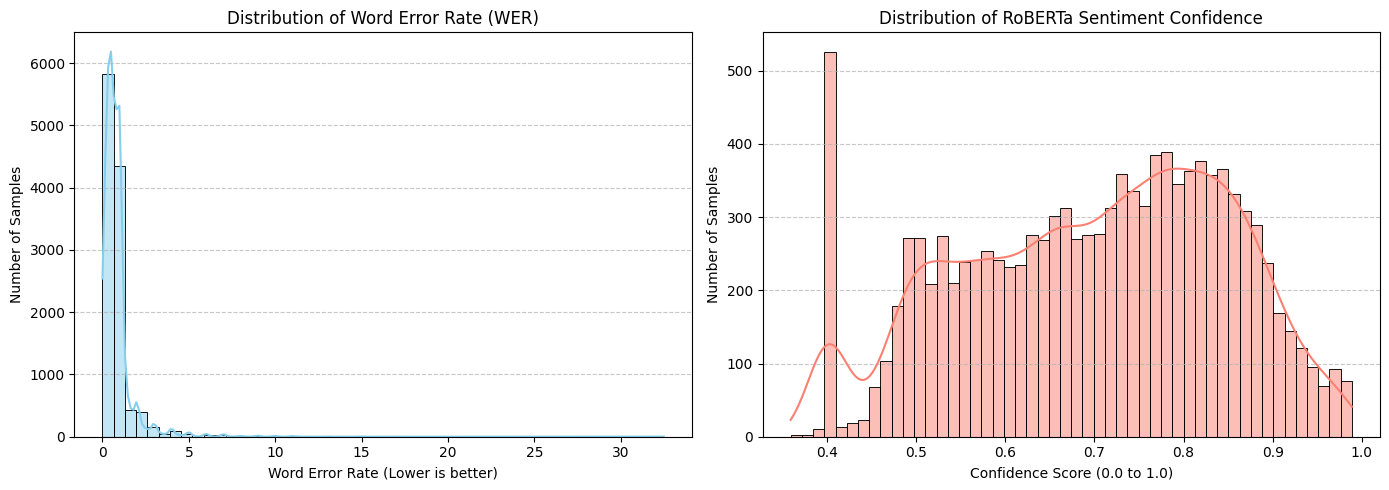

In [6]:
# asr 2
import jiwer

AUDIO_DIRECTORY = "dataset_meld/audio/"
AUDIO_EXT = ".wav"
splits = ['train', 'dev', 'test']

os.makedirs("dataset_meld", exist_ok=True)

# Create a timestamp string for the filenames (e.g., "20260617_2030")
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# --- GLOBAL STATS (per split) ---
stats = defaultdict(int)
failed_samples = []

# Lists to collect data for final graphs
global_wers = []
global_sentiment_scores = []

# Define the text transformation pipeline for accurate WER comparison (Text Normalisation)
transformation = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.Strip()
])

# --- PROCESSING LOOP ---
for split in splits:
    print(f"\n================ {split.upper()} SPLIT ================\n")

    orig_csv = os.path.join("dataset_meld", f"{split}_sent_emo.csv")
    out_csv = os.path.join("dataset_meld", f"prepared_{split}_{timestamp}_sent_emo.csv")

    print(f"Processing: {orig_csv}")
    df = pd.read_csv(orig_csv)

    # --- MOCK RUN MECHANISM ---
    MOCK_MODE = False  # Toggle this to False to run the full dataset
    if MOCK_MODE:
        # Take 10% of the data, sampled randomly
        df = df.sample(frac=0.10, random_state=SEED) 
        print(f"⚠️ MOCK MODE ACTIVE: Processing only 10% of {split} ({len(df)} samples)")
    # --------------------------

    prepared_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        dia_id = row['Dialogue_ID']
        utt_id = row['Utterance_ID']

        raw_path = os.path.join(
            AUDIO_DIRECTORY,
            f"wav_{split}",
            f"dia{dia_id}_utt{utt_id}{AUDIO_EXT}"
        )
        file_path = os.path.abspath(raw_path)

        # ---------------------------
        # Missing audio
        # ---------------------------
        if not os.path.exists(file_path):
            stats["missing_audio"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "missing_audio"
            })
            continue

        # ---------------------------
        # Validate CSV fields
        # ---------------------------
        if pd.isna(row['Emotion']) or pd.isna(row['Sentiment']) or pd.isna(row['Utterance']):
            stats["invalid_csv_data"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "invalid_csv_data"
            })
            continue

        emo_gt = str(row['Emotion']).lower()
        sent_gt = str(row['Sentiment']).lower()
        trans_gt = str(row['Utterance']).strip()

        # ---------------------------
        # ASR transcription (Wav2Vec 2.0)
        # ---------------------------
        try:
            # Wav2Vec 2.0 REQUIRES 16kHz audio. Librosa handles this automatically.
            speech_array, sampling_rate = librosa.load(file_path, sr=16000)
            
            # Process the audio array into the tensor format the model expects
            input_values = processor(
                speech_array, 
                return_tensors="pt", 
                sampling_rate=16000
            ).input_values.to("cuda")

            # Perform transcription while bypassing the cuDNN 1D Conv bug
            with torch.no_grad():
                with torch.backends.cudnn.flags(enabled=False): # <--- THE MAGIC FIX
                    logits = asr_model_2(input_values).logits
            
            # Decode the predicted IDs back into text
            predicted_ids = torch.argmax(logits, dim=-1)
            trans_asr = processor.batch_decode(predicted_ids)[0]
            
            # Wav2Vec outputs all UPPERCASE without punctuation. 
            # Lowercase it here to keep it consistent with your pipeline.
            trans_asr = trans_asr.lower().strip()

        except Exception as e:
            stats["asr_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "asr_failed", "error": str(e)
            })
            continue
        
        # ---------------------------
        # WER Calculation (Text Normalisation applied)
        # ---------------------------
        wer_score = jiwer.wer(transformation(trans_gt), transformation(trans_asr))

        # ---------------------------
        # Sentiment prediction
        # ---------------------------
        try:
            bert_out = sentiment_classifier(trans_asr)[0]
            sent_pred = bert_out['label'].lower()
            sent_score = bert_out['score']

        except Exception as e:
            stats["sentiment_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "sentiment_failed", "error": str(e)
            })
            continue

        # ---------------------------
        # SUCCESS CASE
        # ---------------------------
        prepared_data.append({
            'emotion': emo_gt,
            'sentiment': sent_gt,  
            'textual_sentiment_predicted': sent_pred,
            'textual_sentiment_score': sent_score,
            'transcription_ground_truth': trans_gt,
            'transcription_ASR': trans_asr,
            'WER': wer_score,
            'file_path': file_path
        })

        stats["success"] += 1
        global_wers.append(wer_score)
        global_sentiment_scores.append(sent_score)

    # ---------------------------
    # Save entire batch at once (Optimised for GPU speed)
    # ---------------------------
    if prepared_data:
        chunk_df = pd.DataFrame(prepared_data)
        chunk_df.to_csv(out_csv, index=False)

    print(f"\n✅ Finished {split}. Saved to {out_csv}")

# ---------------------------
# FINAL REPORT
# ---------------------------
print("\n================ FINAL DATASET REPORT ================\n")

total_failures = (
    stats["missing_audio"] + stats["invalid_csv_data"] +
    stats["asr_failed"] + stats["empty_transcription"] +
    stats["sentiment_failed"]
)

# Calculate Averages
avg_wer = sum(global_wers) / len(global_wers) if global_wers else 0
avg_sent = sum(global_sentiment_scores) / len(global_sentiment_scores) if global_sentiment_scores else 0

print(f"Success samples           : {stats['success']}")
print(f"Missing audio             : {stats['missing_audio']}")
print(f"Invalid CSV data          : {stats['invalid_csv_data']}")
print(f"ASR failed                : {stats['asr_failed']}")
print(f"Empty transcription       : {stats['empty_transcription']}")
print(f"Sentiment prediction fail : {stats['sentiment_failed']}")
print(f"TOTAL FAILURES            : {total_failures}")
print("-" * 54)
print(f"Average WER               : {avg_wer:.4f}")
print(f"Average Sentiment Score   : {avg_sent:.4f}")

# ---------------------------
# SAVE FAILURE LOG
# ---------------------------
failed_df = pd.DataFrame(failed_samples)
log_filename = f"dataset_meld/failed_samples_log_{timestamp}.csv"
failed_df.to_csv(log_filename, index=False)

print(f"\nFailure log saved: {log_filename}")

# ---------------------------
# GENERATE DISTRIBUTION GRAPHS
# ---------------------------
if global_wers and global_sentiment_scores:
    plt.figure(figsize=(14, 5))

    # Graph 1: WER Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(global_wers, bins=50, kde=True, color='skyblue')
    plt.title("Distribution of Word Error Rate (WER)")
    plt.xlabel("Word Error Rate (Lower is better)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Graph 2: Sentiment Score Distribution
    plt.subplot(1, 2, 2)
    sns.histplot(global_sentiment_scores, bins=50, kde=True, color='salmon')
    plt.title("Distribution of RoBERTa Sentiment Confidence")
    plt.xlabel("Confidence Score (0.0 to 1.0)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [5]:
df_train = pd.read_csv("dataset_meld\prepared_train_20260618_1713_sent_emo.csv")
df_dev = pd.read_csv("dataset_meld\prepared_dev_20260618_1713_sent_emo.csv")
df_test = pd.read_csv("dataset_meld\prepared_test_20260618_1713_sent_emo.csv")

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9661 entries, 0 to 9660
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   emotion                      9661 non-null   object 
 1   sentiment                    9661 non-null   object 
 2   textual_sentiment_predicted  9661 non-null   object 
 3   textual_sentiment_score      9661 non-null   float64
 4   transcription_ground_truth   9661 non-null   object 
 5   transcription_ASR            9661 non-null   object 
 6   WER                          9661 non-null   float64
 7   file_path                    9661 non-null   object 
dtypes: float64(2), object(6)
memory usage: 603.9+ KB


In [9]:
df_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   emotion                      1054 non-null   object 
 1   sentiment                    1054 non-null   object 
 2   textual_sentiment_predicted  1054 non-null   object 
 3   textual_sentiment_score      1054 non-null   float64
 4   transcription_ground_truth   1054 non-null   object 
 5   transcription_ASR            1054 non-null   object 
 6   WER                          1054 non-null   float64
 7   file_path                    1054 non-null   object 
dtypes: float64(2), object(6)
memory usage: 66.0+ KB


In [10]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339 entries, 0 to 338
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   emotion                      339 non-null    object 
 1   sentiment                    339 non-null    object 
 2   textual_sentiment_predicted  339 non-null    object 
 3   textual_sentiment_score      339 non-null    float64
 4   transcription_ground_truth   339 non-null    object 
 5   transcription_ASR            339 non-null    object 
 6   WER                          339 non-null    float64
 7   file_path                    339 non-null    object 
dtypes: float64(2), object(6)
memory usage: 21.3+ KB


# 2. Acoustic Feature Extraction

In [7]:
import os
import gc
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm
from datetime import datetime

# ==========================================
# 1. CONFIGURATION
# ==========================================
SR = 16000
MAX_DURATION = 3
MAX_SAMPLES = SR * MAX_DURATION
N_MFCC = 40
MAX_MFCC_LEN = 94 

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

csv_files = {
    'train': "dataset_meld/prepared_train_20260618_1713_sent_emo.csv",
    'dev': "dataset_meld/prepared_dev_20260618_1713_sent_emo.csv",
    'test': "dataset_meld/prepared_test_20260618_1713_sent_emo.csv"
}

# Notice: We no longer need to generate thousands of column names!

print(f"Starting Independent Feature Extraction to NPZ (Timestamp: {timestamp})...\n")

# ==========================================
# 2. EXTRACTION & SAVING LOOP (Per Split)
# ==========================================
for split, path in csv_files.items():
    if not os.path.exists(path):
        print(f"File not found: {path}")
        continue
        
    print(f"Processing {split.upper()} set from {path}")
    df = pd.read_csv(path)
    
    successful_rows = []
    mfcc_data = []
    stats_data = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        file_path = row['file_path']
        
        try:
            # 1. Load Audio
            y, _ = librosa.load(file_path, sr=SR)
            
            # 2. Safeguard against ultra-short clips
            if len(y) < 500:
                continue
                
            # 3. Pad or Crop to exactly 3 seconds
            if len(y) > MAX_SAMPLES:
                y = y[:MAX_SAMPLES]
            else:
                y = np.pad(y, (0, int(MAX_SAMPLES - len(y))), 'constant')
                
            # 4. Extract MFCC
            mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC).T
            if mfcc.shape[0] > MAX_MFCC_LEN:
                mfcc = mfcc[:MAX_MFCC_LEN, :]
            else:
                mfcc = np.pad(mfcc, ((0, MAX_MFCC_LEN - mfcc.shape[0]), (0, 0)), 'constant')
                
            # 5. Extract Statistical Features
            chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=SR).T, axis=0)
            contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=SR).T, axis=0)
            zcr = np.mean(librosa.feature.zero_crossing_rate(y=y).T, axis=0)
            rms = np.mean(librosa.feature.rms(y=y).T, axis=0)
            
            stats = np.hstack([chroma, contrast, zcr, rms])
            
            # 6. Append to lists 
            successful_rows.append(row)
            mfcc_data.append(mfcc.flatten())
            stats_data.append(stats)
            
        except Exception as e:
            continue

    # ==========================================
    # 3. BUILD ARRAYS & SAVE FOR THIS SPLIT
    # ==========================================
    if successful_rows:
        print(f"Constructing NPZ archive for {split.upper()}...")
        
        # Convert the original rows back into a DataFrame to format them cleanly
        df_meta = pd.DataFrame(successful_rows).reset_index(drop=True)
        if 'split' not in df_meta.columns:
            df_meta.insert(0, 'split', split)
            
        out_npz = f"dataset_meld/all_features_{split}_{timestamp}.npz"
        print(f"Saving {split.upper()} to {out_npz}...")

        # Convert numerical lists to strict numpy arrays (float32 saves 50% memory)
        np_mfcc = np.array(mfcc_data, dtype=np.float32)
        np_stats = np.array(stats_data, dtype=np.float32)
        
        # Convert metadata to numpy structures
        np_meta = df_meta.to_numpy(dtype=str)
        meta_cols = df_meta.columns.to_numpy(dtype=str)

        # Save as a compressed NumPy archive
        np.savez_compressed(
            out_npz,
            mfcc=np_mfcc,
            stats=np_stats,
            meta=np_meta,
            meta_cols=meta_cols
        )
        print(f"{split.upper()} Matrix shapes -> Meta: {np_meta.shape}, MFCC: {np_mfcc.shape}, Stats: {np_stats.shape}\n")
    else:
        print(f"No valid samples extracted for {split.upper()}.\n")

    # ==========================================
    # 4. MEMORY CLEANUP
    # ==========================================
    del successful_rows, mfcc_data, stats_data, df_meta, np_mfcc, np_stats, np_meta
    gc.collect()

print("All splits processed and saved independently as NPZ archives!")

Starting Independent Feature Extraction to NPZ (Timestamp: 20260619_1321)...

Processing TRAIN set from dataset_meld/prepared_train_20260618_1713_sent_emo.csv


100%|██████████| 9661/9661 [02:08<00:00, 75.02it/s]


Constructing NPZ archive for TRAIN...
Saving TRAIN to dataset_meld/all_features_train_20260619_1321.npz...
TRAIN Matrix shapes -> Meta: (9661, 9), MFCC: (9661, 3760), Stats: (9661, 21)

Processing DEV set from dataset_meld/prepared_dev_20260618_1713_sent_emo.csv


100%|██████████| 1054/1054 [00:15<00:00, 69.43it/s]


Constructing NPZ archive for DEV...
Saving DEV to dataset_meld/all_features_dev_20260619_1321.npz...
DEV Matrix shapes -> Meta: (1054, 9), MFCC: (1054, 3760), Stats: (1054, 21)

Processing TEST set from dataset_meld/prepared_test_20260618_1713_sent_emo.csv


100%|██████████| 339/339 [00:04<00:00, 69.77it/s]


Constructing NPZ archive for TEST...
Saving TEST to dataset_meld/all_features_test_20260619_1321.npz...
TEST Matrix shapes -> Meta: (339, 9), MFCC: (339, 3760), Stats: (339, 21)

All splits processed and saved independently as NPZ archives!
